# 03 — Feature Engineering

Apply the full feature pipeline to each of the three resampled datasets, validate the outputs, and inspect feature distributions and correlations.

**Features built:**
- Lagged log-returns: `ret_1`, `ret_2`, `ret_4`, `ret_6`, `ret_12`, `ret_24`
- RSI(14), MACD(12/26/9), Bollinger Band width, ATR(14)
- Volume z-score (24-period rolling)
- Hour of day, day of week
- Binary target: `1` if next close > current close

In [1]:
import sys
from pathlib import Path

# Resolve project root robustly (works in VS Code Jupyter where CWD = workspace root)
try:
    ROOT = Path(__vsc_ipynb_file__).parent.parent.resolve()
except NameError:
    ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.features import (
    build_features,
    get_feature_cols,
    create_windows,
    DEFAULT_LAGS,
)

sns.set_theme(style='darkgrid', palette='muted')
PROCESSED = ROOT / 'data' / 'processed'

## 1. Build Features for All Horizons

In [2]:
raw_frames = {}
for label in ['5m', '30m', '1h']:
    path = PROCESSED / f'btc_{label}.csv'
    raw_frames[label] = pd.read_csv(path, index_col='timestamp', parse_dates=True)

# Build features for each timeframe
feat_frames = {}
for label, df in raw_frames.items():
    print(f"\n=== {label} ===")
    feat_frames[label] = build_features(df)


=== 5m ===
[features] Building features  (rows before: 758,593) …
[features] Dropped 34 NaN rows (indicator warm-up + label shift)
[features] Done  (rows after: 758,559,  features: 15)

=== 30m ===
[features] Building features  (rows before: 126,433) …
[features] Dropped 34 NaN rows (indicator warm-up + label shift)
[features] Done  (rows after: 126,399,  features: 15)

=== 1h ===
[features] Building features  (rows before: 63,217) …
[features] Dropped 34 NaN rows (indicator warm-up + label shift)
[features] Done  (rows after: 63,183,  features: 15)


In [3]:
# Inspect feature columns
feat_cols = get_feature_cols(feat_frames['1h'])
print(f"Total features: {len(feat_cols)}")
print(feat_cols)

Total features: 15
['ret_1', 'ret_2', 'ret_4', 'ret_6', 'ret_12', 'ret_24', 'rsi_14', 'macd', 'macd_signal', 'macd_hist', 'bb_width', 'atr_14', 'vol_zscore', 'hour', 'day_of_week']


In [4]:
# Sample output for 1h
feat_frames['1h'][feat_cols + ['target']].tail()

,ret_1,ret_2,ret_4,ret_6,ret_12,ret_24,rsi_14,macd,macd_signal,macd_hist,bb_width,atr_14,vol_zscore,hour,day_of_week,target
timestamp,,,,,,,,,,,,,,,,
2026-03-18 19:00:00+00:00,-0.000343,-0.007329,-0.005548,-0.014820,-0.038795,-0.047264,27.096380,-787.698084,-542.157171,-245.540913,0.069386,610.500571,-0.124324,19,2,1.0
2026-03-18 20:00:00+00:00,0.002000,0.001657,-0.001395,0.000301,-0.038973,-0.045191,29.628216,-797.089310,-593.143599,-203.945711,0.071746,626.416959,0.316792,20,2,1.0
2026-03-18 21:00:00+00:00,0.000688,0.002688,-0.004642,-0.002861,-0.040122,-0.046898,30.523032,-791.454638,-632.805807,-158.648831,0.072658,601.963605,-0.967930,21,2,0.0
2026-03-18 22:00:00+00:00,-0.001545,-0.000857,0.000800,-0.002252,-0.038498,-0.043364,29.612631,-786.796309,-663.603907,-123.192402,0.072173,582.141919,-0.689570,22,2,1.0
2026-03-18 23:00:00+00:00,0.001304,-0.000240,0.002447,-0.004882,-0.023667,-0.036693,31.471093,-766.771051,-684.237336,-82.533715,0.069886,561.682496,-0.440275,23,2,0.0


## 2. Feature Distributions

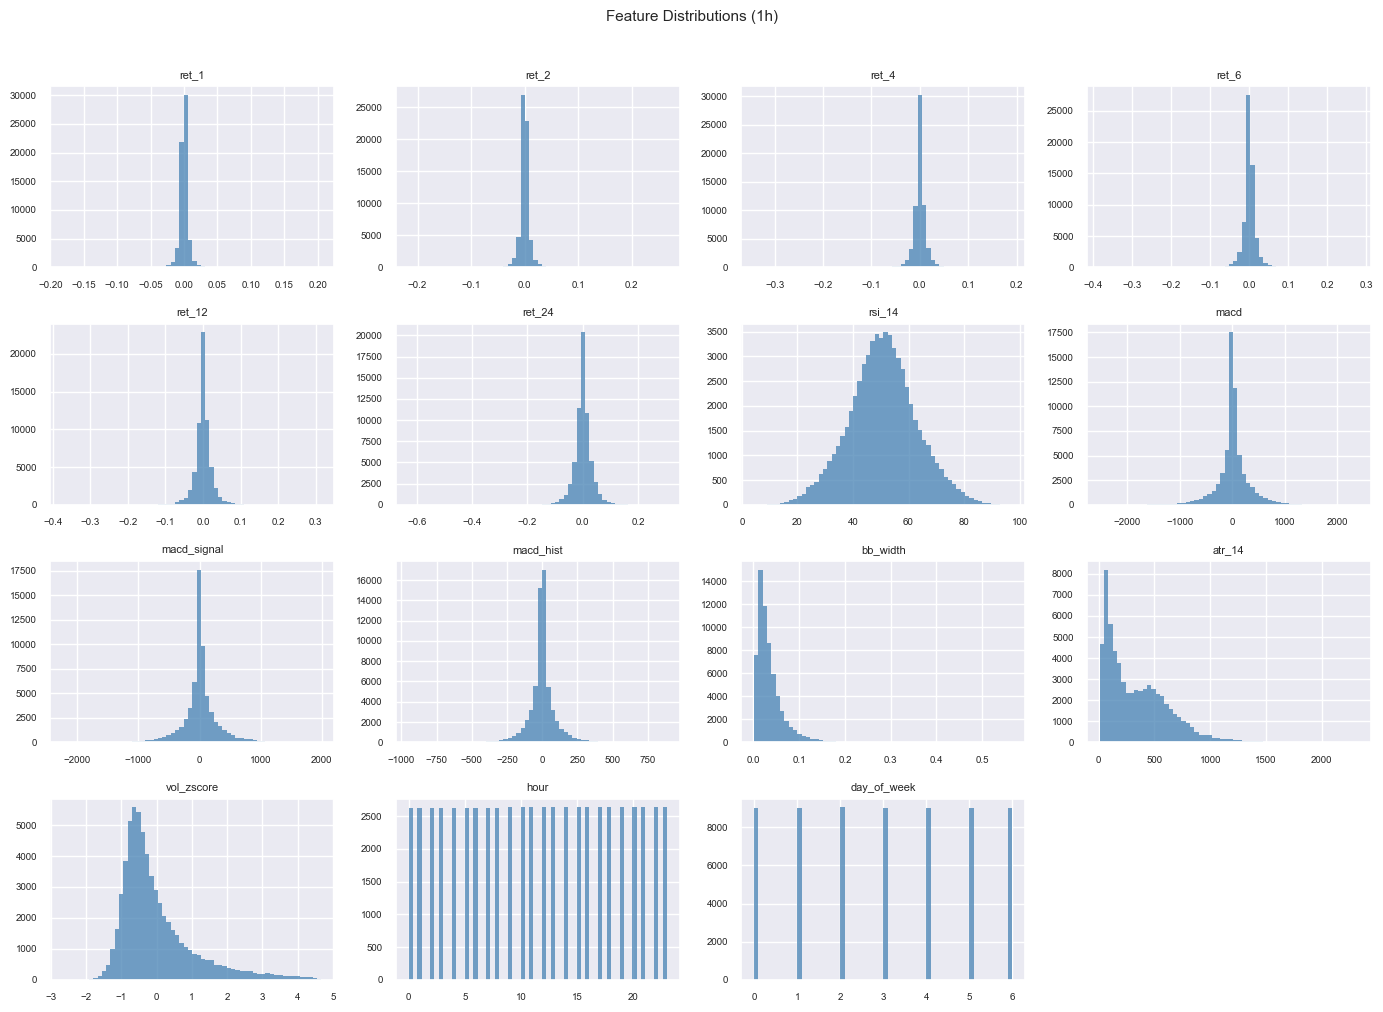

In [5]:
df = feat_frames['1h']
feat_cols = get_feature_cols(df)

n_cols = 4
n_rows = int(np.ceil(len(feat_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 2.5))
axes = axes.flatten()

for i, col in enumerate(feat_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=60, color='steelblue', alpha=0.75, edgecolor='none')
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel('')
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions (1h)', y=1.01, fontsize=11)
plt.tight_layout()
plt.show()

## 3. Feature Correlation Matrix

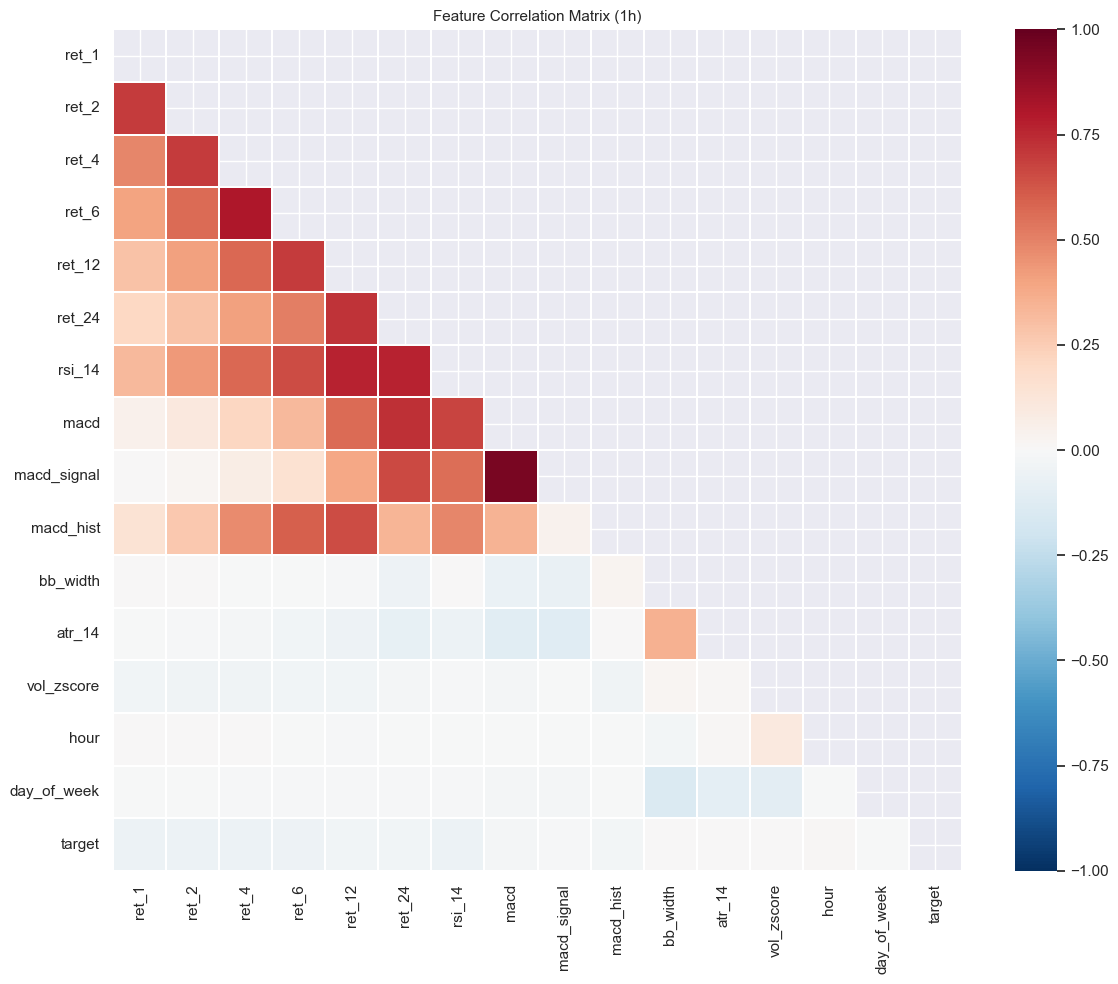

In [6]:
df = feat_frames['1h']
feat_cols = get_feature_cols(df)
corr = df[feat_cols + ['target']].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=False, cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, linewidths=0.3, ax=ax,
)
ax.set_title('Feature Correlation Matrix (1h)', fontsize=11)
plt.tight_layout()
plt.show()

## 4. Feature-Target Correlation (sorted)

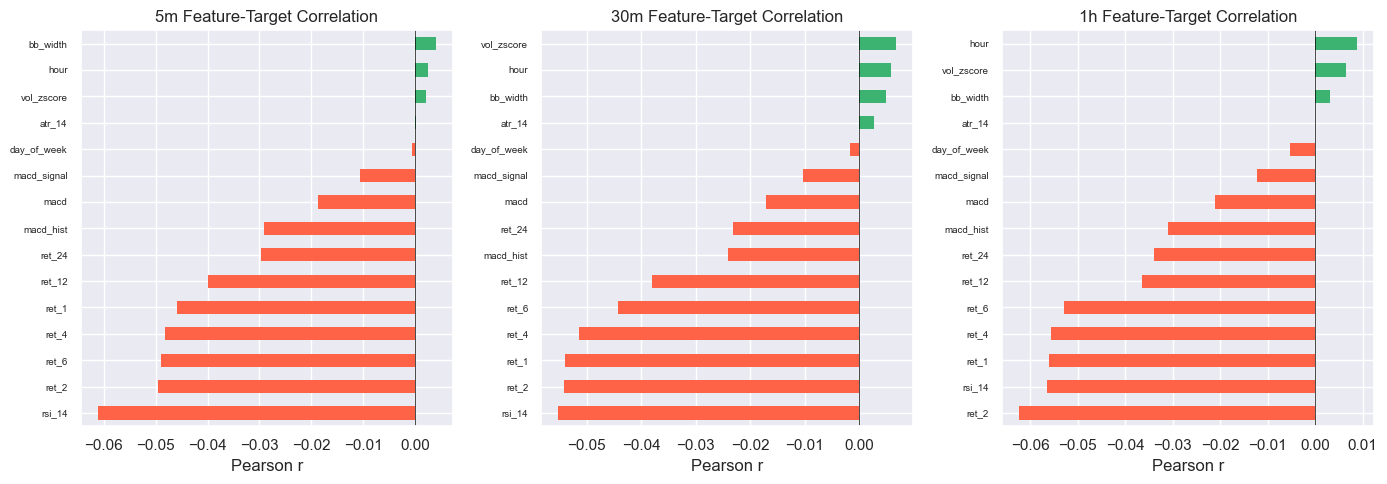

In [7]:
feat_cols = get_feature_cols(feat_frames['1h'])

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, (label, df) in zip(axes, feat_frames.items()):
    fc = get_feature_cols(df)
    target_corr = df[fc].corrwith(df['target']).sort_values()
    colors = ['tomato' if v < 0 else 'mediumseagreen' for v in target_corr.values]
    target_corr.plot(kind='barh', ax=ax, color=colors, edgecolor='none')
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_title(f'{label} Feature-Target Correlation')
    ax.set_xlabel('Pearson r')
    ax.tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.show()

## 5. Sliding Window Arrays (for LSTM / TFT)

Demonstrate `create_windows()` which converts the feature DataFrame  
into 3-D arrays of shape `(n_samples, window_size, n_features)`.

In [8]:
WINDOW_SIZE = 48  # 48 one-hour candles = 2 days of lookback

X, y = create_windows(feat_frames['1h'], window_size=WINDOW_SIZE)

print(f"X shape : {X.shape}  → (samples, window, features)")
print(f"y shape : {y.shape}")
print(f"y mean  : {y.mean():.4f}  (fraction UP)")

[features] Windows: X=(63136, 48, 15), y=(63136,)  (window_size=48, features=15)
X shape : (63136, 48, 15)  → (samples, window, features)
y shape : (63136,)
y mean  : 0.5076  (fraction UP)


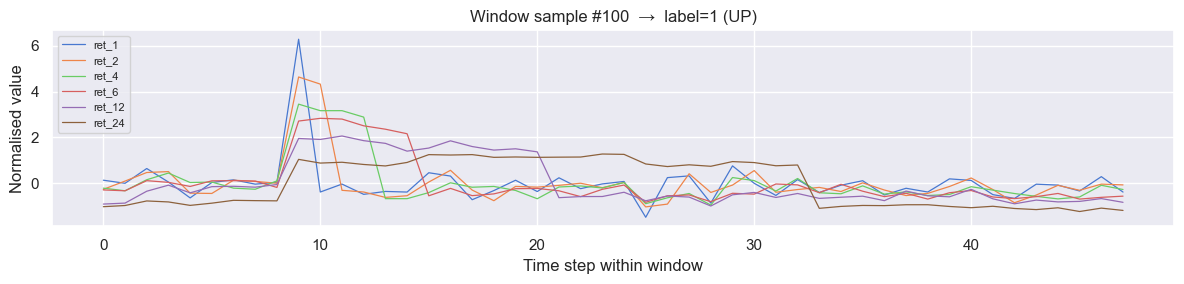

In [9]:
# Visualise one sample window
sample_idx = 100
feat_cols_1h = get_feature_cols(feat_frames['1h'])

fig, ax = plt.subplots(figsize=(12, 3))
for i, col in enumerate(feat_cols_1h[:6]):  # show first 6 features
    series = X[sample_idx, :, i]
    series_norm = (series - series.mean()) / (series.std() + 1e-9)
    ax.plot(series_norm, label=col, linewidth=0.9)

ax.set_title(f'Window sample #{sample_idx}  →  label={int(y[sample_idx])} ({"UP" if y[sample_idx] else "DOWN"})')
ax.set_xlabel('Time step within window')
ax.set_ylabel('Normalised value')
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

## 6. NaN Audit After Feature Engineering

In [10]:
for label, df in feat_frames.items():
    nan_count = df.isnull().sum().sum()
    print(f"{label:>4s}: {nan_count} NaN values remaining  ({len(df):,} total rows)")

  5m: 0 NaN values remaining  (758,559 total rows)
 30m: 0 NaN values remaining  (126,399 total rows)
  1h: 0 NaN values remaining  (63,183 total rows)
